# Introduction à l'IA : TD2 - régression linéaire multiple
## ARSENA Claire - Groupe A1

## Exercice 1 - Chargement des données

In [43]:
#1. Import de la bibliothèque pandas
import pandas as pd

#2. Lecture du fichier excel
df = pd.read_excel ('Multivariate_Linear_Regression_dataset.xlsx')

#3. Renvoi du début du dataframe
print("Début du fichier excel : \n", df.head())

#4. Récupération de nos variables 
y = df[['prix']] #VD
x = df[['taille_en_pieds_carre', 'nb_chambres']] #VIs

print('\n Affichage de notre variable dépendante y \n', y.head())
print ('\n Affichage de nos variables indépendantes x \n', x.head())

Début du fichier excel : 
    taille_en_pieds_carre  nb_chambres    prix
0                   2104            3  399900
1                   1600            3  329900
2                   2400            3  369000
3                   1416            2  232000
4                   3000            4  539900

 Affichage de notre variable dépendante y 
      prix
0  399900
1  329900
2  369000
3  232000
4  539900

 Affichage de nos variables indépendantes x 
    taille_en_pieds_carre  nb_chambres
0                   2104            3
1                   1600            3
2                   2400            3
3                   1416            2
4                   3000            4


## Exercice 2 - Représentation du dataset

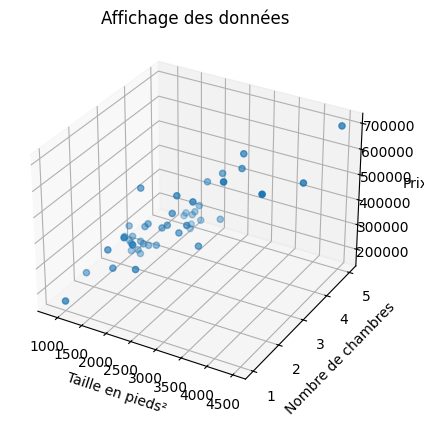


 Prix des maisons en fonction de la taille en pieds carré et du nombre de chambres


In [44]:
#Import de matplotlib pour visualiser notre dataset
import matplotlib.pyplot as plt

#Création du modèle
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x['taille_en_pieds_carre'], x['nb_chambres'], y['prix'])
#Légendes
ax.set_xlabel('Taille en pieds²')
ax.set_ylabel('Nombre de chambres')
ax.set_zlabel('Prix')
ax.set_title('Affichage des données')

#Affichage 
plt.show()
print('\n Prix des maisons en fonction de la taille en pieds carré et du nombre de chambres')

## Exercice 3 - Normalisation des données et features scaling

In [45]:
#Import du scaler de la bibliothèque
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print('Affichage que des 5 premiers éléments juste pour vérifier', x_scaled[:5]) 

Affichage que des 5 premiers éléments juste pour vérifier [[ 0.13141542 -0.22609337]
 [-0.5096407  -0.22609337]
 [ 0.5079087  -0.22609337]
 [-0.74367706 -1.5543919 ]
 [ 1.27107075  1.10220517]]


## Exercice 4 - Apprentissage de l'algorithme par les données

In [46]:
#import du module pour la régression
import statsmodels.api as sm

# 1. Création de l'objet OLS
modele = sm.OLS(y, x)

# 2. Approximation de la ligne droite de régression linéaire aux données
resultats = modele.fit()

#3. Tableau descriptif des résultats 

tableau = resultats.summary()
print('Voici le tableau avec un x sans constante \n', tableau)

#4.
x_avec_constante = sm.add_constant(x)
modele_q4 = sm.OLS(y, x_avec_constante)
resultats_q4 = modele_q4.fit()
tableau_q4 = resultats_q4.summary()
print('\nVoici le tableau avec un x avec constante \n', tableau_q4)

Voici le tableau avec un x sans constante 
                                  OLS Regression Results                                
Dep. Variable:                   prix   R-squared (uncentered):                   0.966
Model:                            OLS   Adj. R-squared (uncentered):              0.964
Method:                 Least Squares   F-statistic:                              631.4
Date:                Tue, 06 Jan 2026   Prob (F-statistic):                    1.19e-33
Time:                        12:11:08   Log-Likelihood:                         -589.11
No. Observations:                  47   AIC:                                      1182.
Df Residuals:                      45   BIC:                                      1186.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                            coef    std err          t      P>|t|      [0.02

## Exercice 5 - Visualisation de la fonction de prédiction

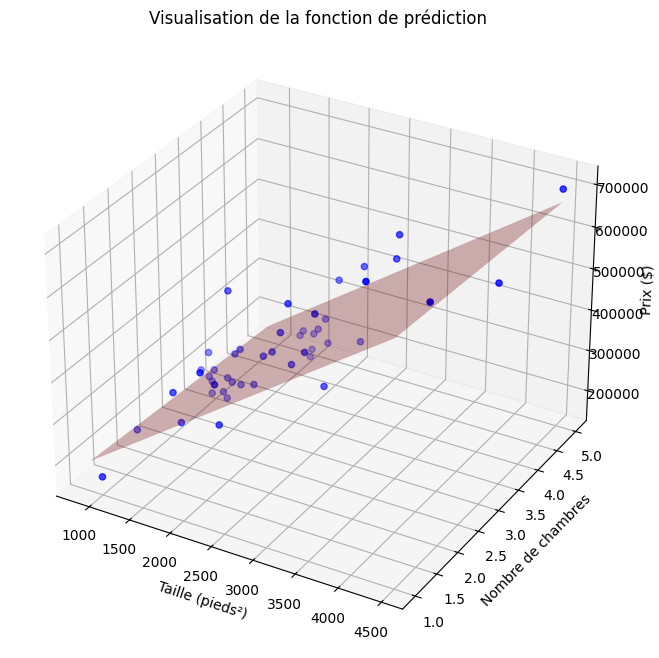

In [47]:
import numpy as np

# On récupère nos 3 coefficients du modele et on reprend la question 4 de l'exercice 4 pour avoir les VI avec une constante
coefs = resultats_q4.params
a0 = coefs['const']
a1 = coefs['taille_en_pieds_carre']
a2 = coefs['nb_chambres']

# Prédiction
def prix_estime(taille, nb_chambres):
    return a0 + a1 * taille + a2 * nb_chambres

#Graphique
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x['taille_en_pieds_carre'], x['nb_chambres'], y['prix'], c='blue', marker='o', label='Données réelles')
x_surf = np.linspace(x['taille_en_pieds_carre'].min(), x['taille_en_pieds_carre'].max(), 20)
y_surf = np.linspace(x['nb_chambres'].min(), x['nb_chambres'].max(), 20)
x_surf, y_surf = np.meshgrid(x_surf, y_surf)

# prédiction du prix par grille
z_surf = prix_estime(x_surf, y_surf)

ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.3)

#Etiquettes et titres
ax.set_xlabel('Taille (pieds²)')
ax.set_ylabel('Nombre de chambres')
ax.set_zlabel('Prix ($)')
ax.set_title('Visualisation de la fonction de prédiction')

plt.show()

## Exercice 6 - Test de prédiction

In [48]:
#réutilisation des coefs de l'exercice 4
coefs = resultats_q4.params

a0 = coefs['const']                  
a1 = coefs['taille_en_pieds_carre']  
a2 = coefs['nb_chambres']            

def predict_price_of_house(taille, nb_chambres):
    prix_estime = a0 + (a1 * taille) + (a2 * nb_chambres)
    return prix_estime

# Test avec les valeurs de l'énoncé
prix_final = predict_price_of_house(4500, 5)

print('Prix estimé', prix_final)

Prix estimé 672355.8470604729
